# Exercice EDA — Analyse Exploratoire des Données sur le Dataset Ames Housing

**Objectif** : Réaliser une analyse exploratoire complète du dataset Ames Housing en appliquant les concepts du cours : statistiques descriptives, visualisations, détection d'anomalies, feature engineering et formulation d'hypothèses.

**Dataset** : `AmesHousing.csv` — Ventes de maisons à Ames, Iowa (USA), 2006-2010 (~2930 observations, 82 variables).

---
## Section 1 — Importation des bibliothèques et chargement des données

Importez les bibliothèques nécessaires : `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy.stats`. Chargez ensuite le fichier `AmesHousing.csv` et affichez les premières lignes pour vérifier le bon chargement.

In [ ]:
!

In [3]:
# 1.1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


In [4]:
# 1.2 — Chargement des données
df = pd.read_csv("AmesHousing.csv")

# Vérification du chargement
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


---
## Section 2 — Exploration initiale de la structure des données

**Objectif** : Comprendre la structure du DataFrame (dimensions, types de colonnes, valeurs non-nulles) et identifier les problèmes évidents de qualité.

### 2.1 Structure du dataset
Utilisez `df.shape`, `df.info()`, `df.dtypes` et `df.describe()` pour explorer la structure du dataset.

In [5]:
# 2.1 — Structure du dataset
# TODO : Affichez les dimensions, les informations générales et les statistiques descriptives
print("Dimensions :", df.shape)
print("\n--- Informations générales ---")
df.info()


Dimensions : (2197, 82)

--- Informations générales ---
<class 'pandas.DataFrame'>
RangeIndex: 2197 entries, 0 to 2196
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2197 non-null   int64  
 1   PID              2197 non-null   int64  
 2   MS SubClass      2197 non-null   int64  
 3   MS Zoning        2197 non-null   str    
 4   Lot Frontage     1835 non-null   float64
 5   Lot Area         2197 non-null   int64  
 6   Street           2197 non-null   str    
 7   Alley            143 non-null    str    
 8   Lot Shape        2197 non-null   str    
 9   Land Contour     2197 non-null   str    
 10  Utilities        2197 non-null   str    
 11  Lot Config       2197 non-null   str    
 12  Land Slope       2197 non-null   str    
 13  Neighborhood     2197 non-null   str    
 14  Condition 1      2197 non-null   str    
 15  Condition 2      2197 non-null   str    
 16  Bldg Type      

In [6]:
# 2.1 (suite) — Statistiques descriptives de base
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2197.000000,2.197000e+03,2197.000000,1835.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2175.000000,...,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000
mean,1460.512517,7.127872e+08,57.064178,69.549319,10268.070096,6.116523,5.552572,1972.030951,1984.781065,105.101609,...,92.436959,48.768320,22.393719,2.361402,15.954028,2.789713,57.404188,6.189804,2007.793810,182376.851161
std,846.537251,1.887751e+08,42.360690,23.188224,7975.740885,1.429613,1.107019,30.450069,20.898245,184.897165,...,121.422842,69.127588,62.063281,22.843004,56.495484,39.991010,639.103790,2.746902,1.314345,81168.157405
min,1.000000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,13100.000000
25%,733.000000,5.284410e+08,20.000000,58.500000,7500.000000,5.000000,5.000000,1954.000000,1966.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,130000.000000
50%,1452.000000,5.354532e+08,50.000000,69.000000,9488.000000,6.000000,5.000000,1975.000000,1994.000000,0.000000,...,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163500.000000
75%,2196.000000,9.071811e+08,70.000000,80.000000,11660.000000,7.000000,6.000000,2002.000000,2004.000000,166.000000,...,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,215000.000000
max,2929.000000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,870.000000,742.000000,584.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


**Interprétation 2.1** *(à compléter)* :
- Combien de lignes et de colonnes contient le dataset ?
- Quels types de données sont présents (int, float, object) ?
- Y a-t-il des colonnes dont le type vous semble inapproprié ? Lesquelles et pourquoi ?

### 2.2 Évaluation de la qualité des données — Valeurs manquantes

Calculez le nombre et le pourcentage de valeurs manquantes par colonne. Visualisez-les avec une heatmap.

In [7]:
# 2.2 — Valeurs manquantes : comptage et pourcentage
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage (%)': missing_pct})
missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('Pourcentage (%)', ascending=False)
print(f"Colonnes avec valeurs manquantes : {len(missing_df)}")
missing_df

Colonnes avec valeurs manquantes : 27


,Manquantes,Pourcentage (%)
Pool QC,2185,99.453801
Misc Feature,2117,96.358671
Alley,2054,93.491124
Fence,1778,80.928539
Mas Vnr Type,1329,60.491579
Fireplace Qu,1066,48.520710
Lot Frontage,362,16.477014
Garage Qual,122,5.553027
Garage Cond,122,5.553027
Garage Yr Blt,122,5.553027


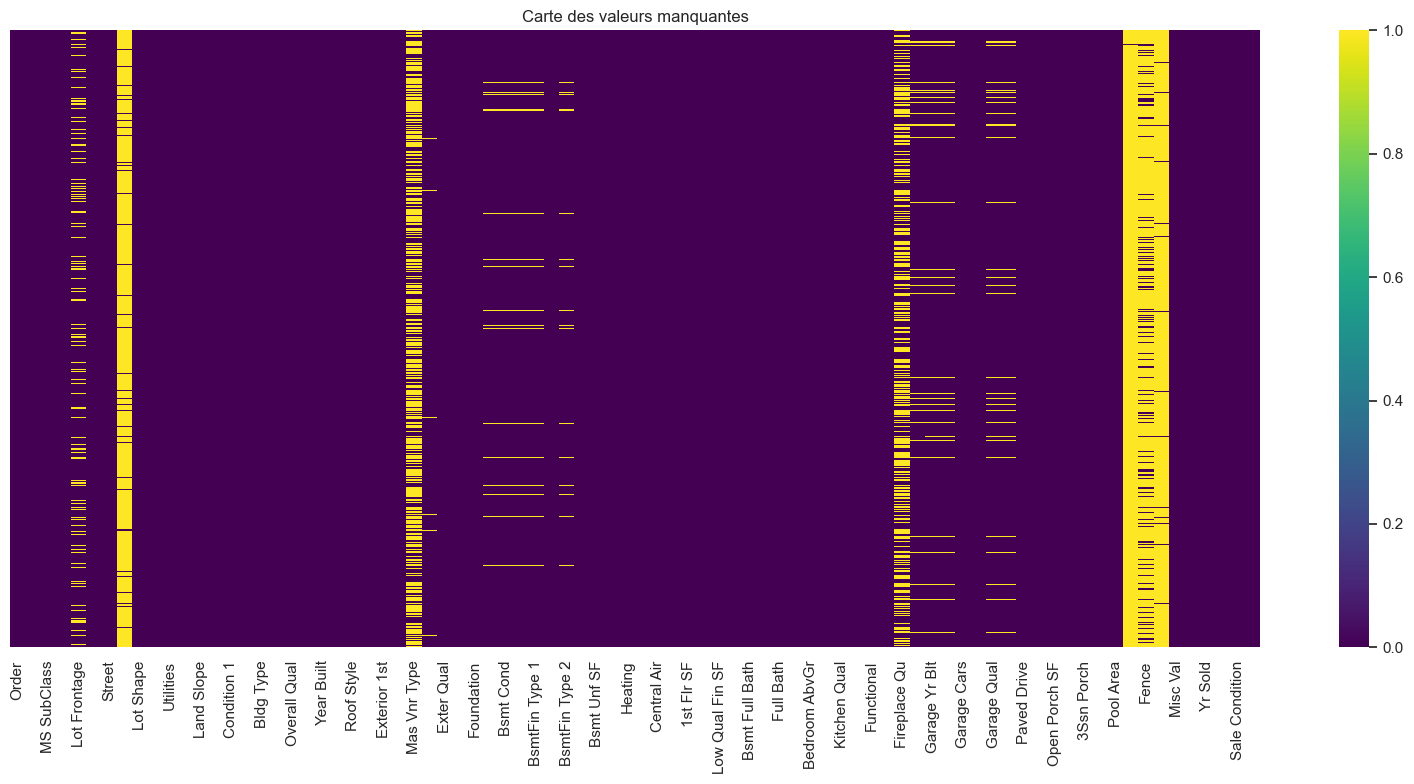

In [8]:
# 2.2 (suite) — Heatmap des valeurs manquantes
plt.figure(figsize=(16, 8))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title("Carte des valeurs manquantes")
plt.tight_layout()
plt.show()

**Interprétation 2.2** *(à compléter)* :
- Combien de colonnes ont des valeurs manquantes ?
- Quelles colonnes ont plus de 50 % de valeurs manquantes ? Qu'est-ce que cela signifie pour l'analyse ?
- Parmi les 5 variables ciblées (`Gr Liv Area`, `SalePrice`, `Lot Area`, `Year Built`, `Overall Qual`), y a-t-il des valeurs manquantes ?

### 2.3 Doublons

Vérifiez si le dataset contient des lignes dupliquées.

In [9]:
# 2.3 — Détection des doublons
n_doublons = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {n_doublons}")

Nombre de lignes dupliquées : 0


### 2.4 Sélection des variables d'intérêt

Créez un DataFrame `df_subset` contenant uniquement les 5 variables ciblées et la colonne `Order` comme identifiant.

In [10]:
# 2.4 — Sélection du sous-ensemble de variables
colonnes_cibles = ['Order', 'Gr Liv Area', 'SalePrice', 'Lot Area', 'Year Built', 'Overall Qual']
df_subset = df[colonnes_cibles].copy()
print(f"Dimensions du sous-ensemble : {df_subset.shape}")
df_subset.head()

Dimensions du sous-ensemble : (2197, 6)


,Order,Gr Liv Area,SalePrice,Lot Area,Year Built,Overall Qual
0,534,1218,159000,9605,2007,7
1,803,2196,271900,14684,1990,7
2,956,1344,137500,14375,1958,6
3,460,1456,248500,6472,2008,9
4,487,1374,167000,9734,2004,7


---
## Section 3 — Statistiques descriptives univariées — Variables quantitatives

**Objectif** : Calculer explicitement les indicateurs classiques et robustes pour chaque variable du subset. Comprendre ce que chaque statistique mesure.

### 3.1 Statistiques classiques
Calculez pour chaque variable : **moyenne**, **écart-type**, **minimum**, **maximum**.

In [11]:
# 3.1 — Statistiques classiques
variables = ['Gr Liv Area', 'SalePrice', 'Lot Area', 'Year Built', 'Overall Qual']

# TODO : Calculez la moyenne, l'écart-type, le min et le max pour chaque variable
for col in variables:
    print(f"\n--- {col} ---")
    print(f"  Moyenne    : {df_subset[col].mean():.2f}")
    print(f"  Écart-type : {df_subset[col].std():.2f}")
    print(f"  Min        : {df_subset[col].min()}")
    print(f"  Max        : {df_subset[col].max()}")


--- Gr Liv Area ---
  Moyenne    : 1507.87
  Écart-type : 511.84
  Min        : 334
  Max        : 5642

--- SalePrice ---
  Moyenne    : 182376.85
  Écart-type : 81168.16
  Min        : 13100
  Max        : 755000

--- Lot Area ---
  Moyenne    : 10268.07
  Écart-type : 7975.74
  Min        : 1300
  Max        : 215245

--- Year Built ---
  Moyenne    : 1972.03
  Écart-type : 30.45
  Min        : 1872
  Max        : 2010

--- Overall Qual ---
  Moyenne    : 6.12
  Écart-type : 1.43
  Min        : 1
  Max        : 10


### 3.2 Statistiques robustes
Calculez pour chaque variable : **médiane**, **Q1** (25e percentile), **Q3** (75e percentile), **IQR** = Q3 − Q1, **MAD** (médiane des écarts absolus à la médiane).

> Calculez le MAD manuellement avec `np.median(np.abs(x - np.median(x)))` pour comprendre ce qu'il mesure.

In [12]:
# 3.2 — Statistiques robustes
for col in variables:
    data = df_subset[col].dropna()
    mediane = np.median(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    mad = np.median(np.abs(data - mediane))
    
    print(f"\n--- {col} ---")
    print(f"  Médiane : {mediane:.2f}")
    print(f"  Q1      : {q1:.2f}")
    print(f"  Q3      : {q3:.2f}")
    print(f"  IQR     : {iqr:.2f}")
    print(f"  MAD     : {mad:.2f}")


--- Gr Liv Area ---
  Médiane : 1452.00
  Q1      : 1142.00
  Q3      : 1762.00
  IQR     : 620.00
  MAD     : 310.00

--- SalePrice ---
  Médiane : 163500.00
  Q1      : 130000.00
  Q3      : 215000.00
  IQR     : 85000.00
  MAD     : 39000.00

--- Lot Area ---
  Médiane : 9488.00
  Q1      : 7500.00
  Q3      : 11660.00
  IQR     : 4160.00
  MAD     : 2082.00

--- Year Built ---
  Médiane : 1975.00
  Q1      : 1954.00
  Q3      : 2002.00
  IQR     : 48.00
  MAD     : 25.00

--- Overall Qual ---
  Médiane : 6.00
  Q1      : 5.00
  Q3      : 7.00
  IQR     : 2.00
  MAD     : 1.00


### 3.3 Statistiques descriptives — Variables qualitatives
Pour `Overall Qual` (variable ordinale), calculez les fréquences absolues et relatives. Identifiez le mode.

In [13]:
# 3.3 — Fréquences pour Overall Qual
print("Fréquences absolues :")
print(df_subset['Overall Qual'].value_counts().sort_index())
print("\nFréquences relatives (%) :")
print((df_subset['Overall Qual'].value_counts(normalize=True).sort_index() * 100).round(2))
print(f"\nMode : {df_subset['Overall Qual'].mode()[0]}")

Fréquences absolues :
Overall Qual
1       4
2      10
3      33
4     162
5     611
6     540
7     460
8     268
9      82
10     27
Name: count, dtype: int64

Fréquences relatives (%) :
Overall Qual
1      0.18
2      0.46
3      1.50
4      7.37
5     27.81
6     24.58
7     20.94
8     12.20
9      3.73
10     1.23
Name: proportion, dtype: float64

Mode : 5


### 3.4 Statistiques robustes vs classiques — Comparaison

Comparez les statistiques classiques et robustes côte à côte. Montrez comment les outliers affectent les statistiques classiques mais pas les robustes.

In [14]:
# 3.4 — Tableau comparatif classiques vs robustes
comparaison = {}
for col in variables:
    data = df_subset[col].dropna()
    comparaison[col] = {
        'Moyenne': data.mean(),
        'Médiane': np.median(data),
        'Écart Moy-Méd': data.mean() - np.median(data),
        'Écart-type': data.std(),
        'MAD': np.median(np.abs(data - np.median(data))),
        'IQR': np.percentile(data, 75) - np.percentile(data, 25),
    }

df_comparaison = pd.DataFrame(comparaison).T.round(2)
df_comparaison

,Moyenne,Médiane,Écart Moy-Méd,Écart-type,MAD,IQR
Gr Liv Area,1507.87,1452.0,55.87,511.84,310.0,620.0
SalePrice,182376.85,163500.0,18876.85,81168.16,39000.0,85000.0
Lot Area,10268.07,9488.0,780.07,7975.74,2082.0,4160.0
Year Built,1972.03,1975.0,-2.97,30.45,25.0,48.0
Overall Qual,6.12,6.0,0.12,1.43,1.0,2.0


**Interprétation 3.4** *(à compléter)* :
- Pour quelles variables la moyenne et la médiane sont-elles très proches ? Qu'est-ce que cela indique ?
- Pour quelles variables l'écart est-il le plus important ? Qu'est-ce que cela indique ?
- Quand devrait-on préférer les statistiques robustes aux classiques ?

---
## Section 4 — Z-score classique et Z-score modifié

**Objectif** : Comprendre et calculer le z-score classique puis le z-score modifié. Reproduire l'exemple du cours (élèves A et B) et comparer les deux méthodes sur les données réelles.

In [15]:
# 4.1 — Exemple concret du cours : Z-score classique (Élèves A et B)
# Élève A : 14/20, classe avec moyenne=12, écart-type=2
z_A = (14 - 12) / 2
print(f"Élève A : note=14, z-score = (14-12)/2 = {z_A}")

# Élève B : 13/20, classe avec moyenne=11, écart-type=1.5
z_B = (13 - 11) / 1.5
print(f"Élève B : note=13, z-score = (13-11)/1.5 = {z_B:.2f}")

print(f"\n→ Bien que B ait une note brute inférieure, son z-score ({z_B:.2f}) est plus élevé que celui de A ({z_A}).")

Élève A : note=14, z-score = (14-12)/2 = 1.0
Élève B : note=13, z-score = (13-11)/1.5 = 1.33

→ Bien que B ait une note brute inférieure, son z-score (1.33) est plus élevé que celui de A (1.0).


In [16]:
# 4.2 — Limite du Z-score classique : impact d'une valeur extrême
notes_normales = np.array([8, 10, 12, 14, 16])
notes_avec_erreur = np.array([8, 10, 12, 14, 16, 40])

print("--- Sans valeur extrême ---")
print(f"  Moyenne : {notes_normales.mean():.1f}, Écart-type : {notes_normales.std():.2f}")
print(f"  Z-score de 16 : {(16 - notes_normales.mean()) / notes_normales.std():.2f}")

print("\n--- Avec valeur extrême (40) ---")
print(f"  Moyenne : {notes_avec_erreur.mean():.1f}, Écart-type : {notes_avec_erreur.std():.2f}")
print(f"  Z-score de 40 : {(40 - notes_avec_erreur.mean()) / notes_avec_erreur.std():.2f}")
print("  → Le z-score classique est faible car la moyenne et l'écart-type sont 'tirés' par la valeur extrême.")

--- Sans valeur extrême ---
  Moyenne : 12.0, Écart-type : 2.83
  Z-score de 16 : 1.41

--- Avec valeur extrême (40) ---
  Moyenne : 16.7, Écart-type : 10.75
  Z-score de 40 : 2.17
  → Le z-score classique est faible car la moyenne et l'écart-type sont 'tirés' par la valeur extrême.


In [17]:
# 4.3 — Z-score modifié : solution robuste
# Formule : Z_modifié = 0.6745 * (x - médiane) / MAD
mediane = np.median(notes_avec_erreur)
mad = np.median(np.abs(notes_avec_erreur - mediane))

print(f"Médiane : {mediane}")
print(f"MAD : {mad}")
print(f"\nZ-score modifié de 40 : 0.6745 × (40 - {mediane}) / {mad} = {0.6745 * (40 - mediane) / mad:.2f}")
print(f"Z-score modifié de 0  : 0.6745 × (0 - {mediane}) / {mad}  = {0.6745 * (0 - mediane) / mad:.2f}")
print("\n→ Le z-score modifié de 40 dépasse largement le seuil de 3.5 : détection claire !")

Médiane : 13.0
MAD : 3.0

Z-score modifié de 40 : 0.6745 × (40 - 13.0) / 3.0 = 6.07
Z-score modifié de 0  : 0.6745 × (0 - 13.0) / 3.0  = -2.92

→ Le z-score modifié de 40 dépasse largement le seuil de 3.5 : détection claire !


---
## Section 5 — Analyse de la forme des distributions (Skewness & Kurtosis)

**Objectif** : Calculer le skewness (asymétrie) et le kurtosis (aplatissement) pour chaque variable numérique. Interpréter la forme de chaque distribution.

**Rappels** :
- **Skewness** : positif = queue à droite (moyenne > médiane) | négatif = queue à gauche | ≈ 0 = symétrique
- **Kurtosis** : > 0 = leptokurtique (queues épaisses) | ≈ 0 = mésokurtique (normale) | < 0 = platykurtique (queues fines)

In [18]:
# 5 — Skewness et Kurtosis pour chaque variable
forme_stats = {}
for col in variables:
    data = df_subset[col].dropna()
    sk = stats.skew(data)
    ku = stats.kurtosis(data)
    
    # Interprétation automatique
    if sk > 0.5:
        sk_interp = "Asymétrie positive (queue à droite)"
    elif sk < -0.5:
        sk_interp = "Asymétrie négative (queue à gauche)"
    else:
        sk_interp = "Approximativement symétrique"
    
    if ku > 1:
        ku_interp = "Leptokurtique (queues épaisses)"
    elif ku < -1:
        ku_interp = "Platykurtique (queues fines)"
    else:
        ku_interp = "Mésokurtique (≈ normale)"
    
    forme_stats[col] = {
        'Skewness': round(sk, 3),
        'Interp. Skewness': sk_interp,
        'Kurtosis': round(ku, 3),
        'Interp. Kurtosis': ku_interp
    }

pd.DataFrame(forme_stats).T

,Skewness,Interp. Skewness,Kurtosis,Interp. Kurtosis
Gr Liv Area,1.369,Asymétrie positive (queue à droite),4.893,Leptokurtique (queues épaisses)
SalePrice,1.778,Asymétrie positive (queue à droite),5.48,Leptokurtique (queues épaisses)
Lot Area,12.845,Asymétrie positive (queue à droite),270.597,Leptokurtique (queues épaisses)
Year Built,-0.656,Asymétrie négative (queue à gauche),-0.409,Mésokurtique (≈ normale)
Overall Qual,0.161,Approximativement symétrique,0.096,Mésokurtique (≈ normale)


**Interprétation Section 5** *(à compléter)* :
- Quelles variables présentent une forte asymétrie ? Dans quelle direction ?
- Quelles variables ont un kurtosis élevé ? Qu'est-ce que cela implique pour la détection d'outliers ?
- Quelles variables pourraient nécessiter une transformation (ex. : log) pour se rapprocher d'une distribution normale ?

### 5.1 Tableau récapitulatif complet

Rassemblez toutes les statistiques dans un seul DataFrame propre.

In [19]:
# 5.1 — Tableau récapitulatif de toutes les statistiques
recap = {}
for col in variables:
    data = df_subset[col].dropna()
    mediane = np.median(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    recap[col] = {
        'Moyenne': round(data.mean(), 2),
        'Écart-type': round(data.std(), 2),
        'Min': data.min(),
        'Max': data.max(),
        'Médiane': round(mediane, 2),
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(q3 - q1, 2),
        'MAD': round(np.median(np.abs(data - mediane)), 2),
        'Skewness': round(stats.skew(data), 3),
        'Kurtosis': round(stats.kurtosis(data), 3),
    }

df_recap = pd.DataFrame(recap).T
df_recap

,Moyenne,Écart-type,Min,Max,Médiane,Q1,Q3,IQR,MAD,Skewness,Kurtosis
Gr Liv Area,1507.87,511.84,334.0,5642.0,1452.0,1142.0,1762.0,620.0,310.0,1.369,4.893
SalePrice,182376.85,81168.16,13100.0,755000.0,163500.0,130000.0,215000.0,85000.0,39000.0,1.778,5.480
Lot Area,10268.07,7975.74,1300.0,215245.0,9488.0,7500.0,11660.0,4160.0,2082.0,12.845,270.597
Year Built,1972.03,30.45,1872.0,2010.0,1975.0,1954.0,2002.0,48.0,25.0,-0.656,-0.409
Overall Qual,6.12,1.43,1.0,10.0,6.0,5.0,7.0,2.0,1.0,0.161,0.096


---
## Section 6 — Visualisations univariées

**Objectif** : Visualiser les distributions pour confirmer ou infirmer ce que les statistiques suggèrent.

### 6.1 Variables continues : histogramme + boxplot côte à côte
Pour `Gr Liv Area`, `SalePrice` et `Lot Area`, tracez un histogramme et un boxplot côte à côte avec des lignes verticales pour la moyenne (rouge) et la médiane (bleu pointillé).

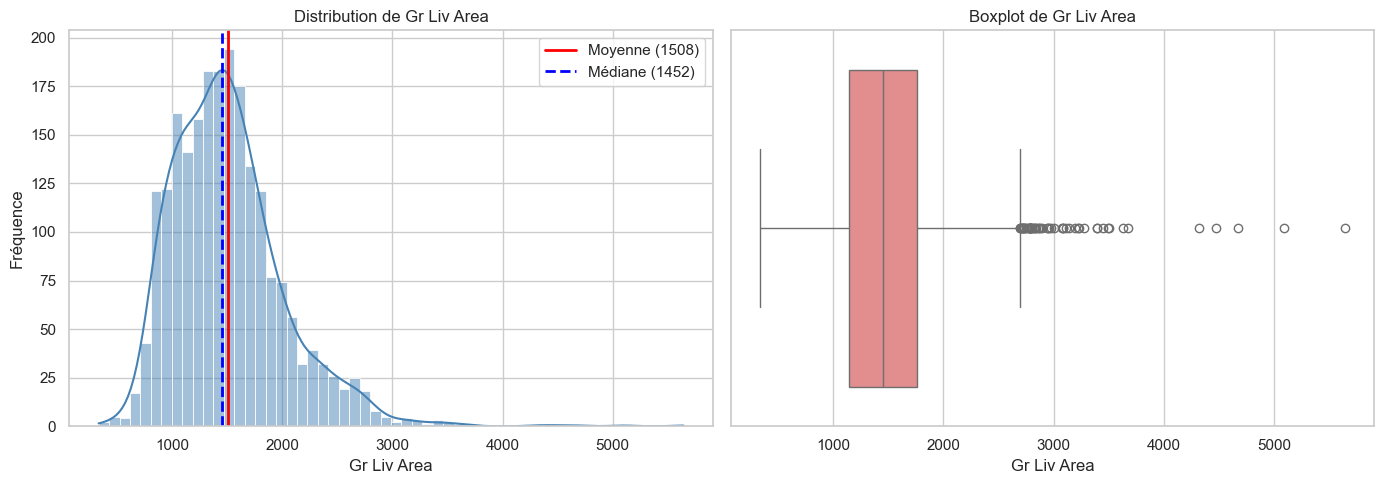

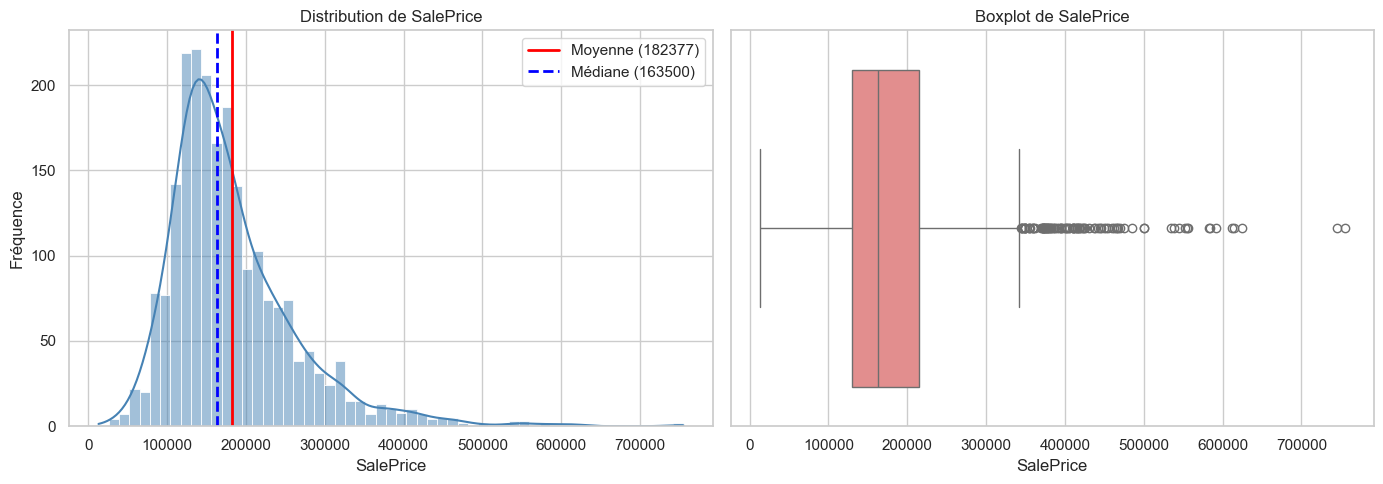

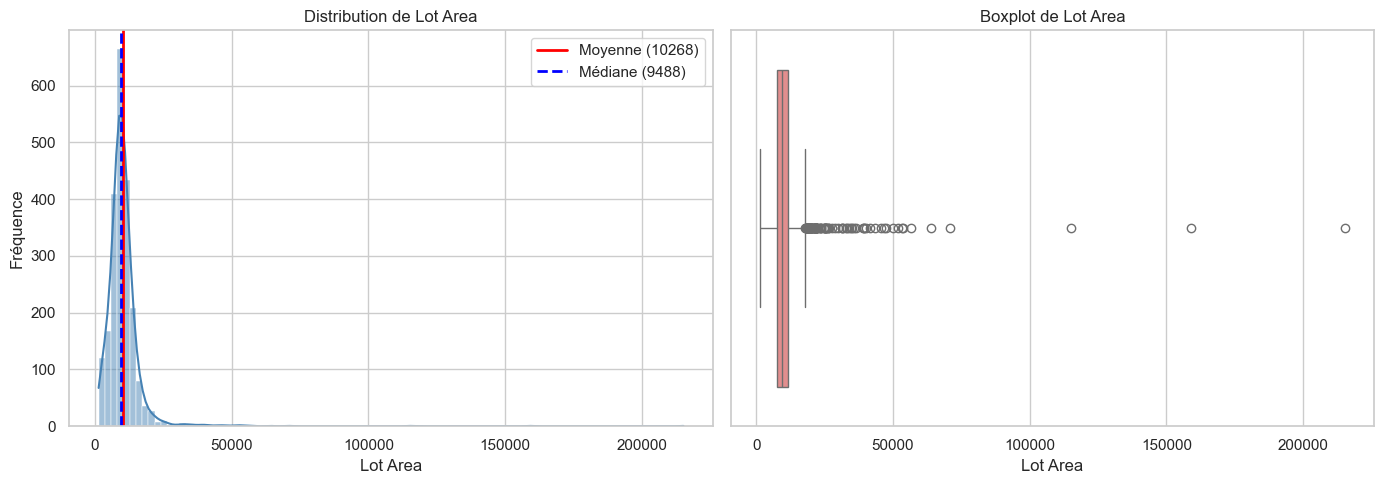

In [20]:
# 6.1 — Histogramme + Boxplot pour les variables continues
variables_continues = ['Gr Liv Area', 'SalePrice', 'Lot Area']

for col in variables_continues:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogramme avec KDE
    sns.histplot(df_subset[col].dropna(), kde=True, ax=axes[0], color='steelblue')
    axes[0].axvline(df_subset[col].mean(), color='red', linestyle='-', linewidth=2, label=f'Moyenne ({df_subset[col].mean():.0f})')
    axes[0].axvline(df_subset[col].median(), color='blue', linestyle='--', linewidth=2, label=f'Médiane ({df_subset[col].median():.0f})')
    axes[0].set_title(f'Distribution de {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Fréquence')
    axes[0].legend()
    
    # Boxplot
    sns.boxplot(x=df_subset[col].dropna(), ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

### 6.2 Variables discrètes : diagrammes en barres
Pour `Year Built` et `Overall Qual`, tracez un diagramme en barres des effectifs.

C:\Users\ethan\AppData\Local\Temp\ipykernel_13588\3870552085.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Overall Qual', data=df_subset, ax=axes[0], palette='viridis')
C:\Users\ethan\AppData\Local\Temp\ipykernel_13588\3870552085.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Décennie', data=df_subset, ax=axes[1], palette='coolwarm')


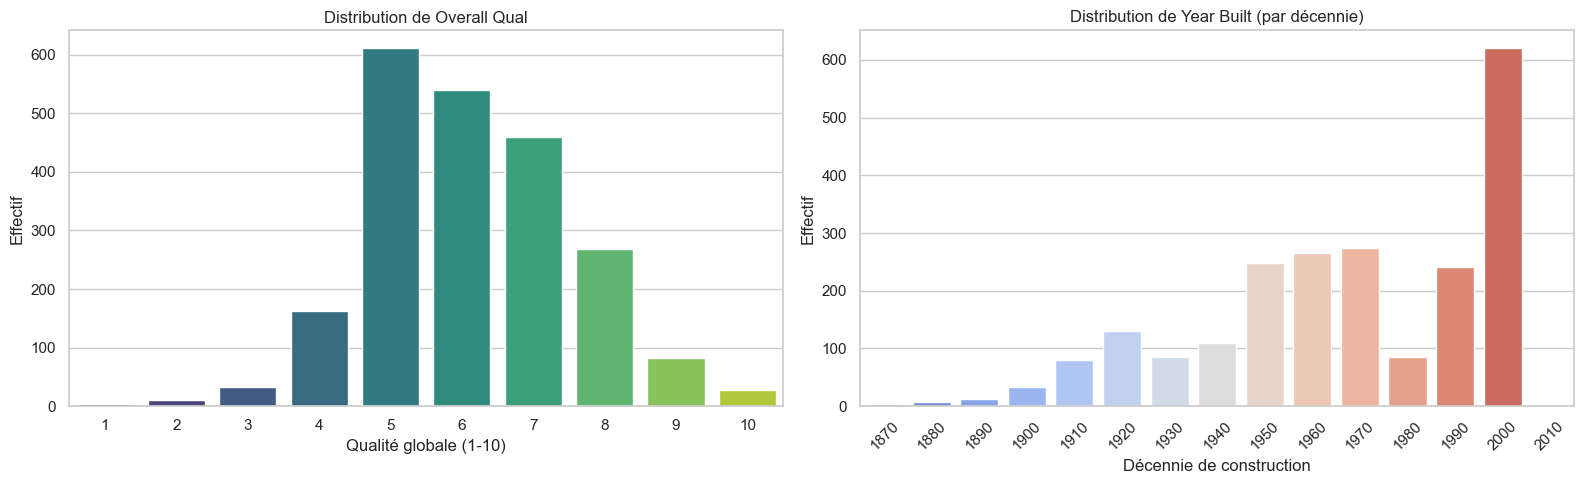

In [21]:
# 6.2 — Diagrammes en barres pour les variables discrètes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall Qual
sns.countplot(x='Overall Qual', data=df_subset, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution de Overall Qual')
axes[0].set_xlabel('Qualité globale (1-10)')
axes[0].set_ylabel('Effectif')

# Year Built (groupé par décennie pour lisibilité)
df_subset['Décennie'] = (df_subset['Year Built'] // 10) * 10
sns.countplot(x='Décennie', data=df_subset, ax=axes[1], palette='coolwarm')
axes[1].set_title('Distribution de Year Built (par décennie)')
axes[1].set_xlabel('Décennie de construction')
axes[1].set_ylabel('Effectif')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 6.3 Visualisations complémentaires : KDE et Violin plots

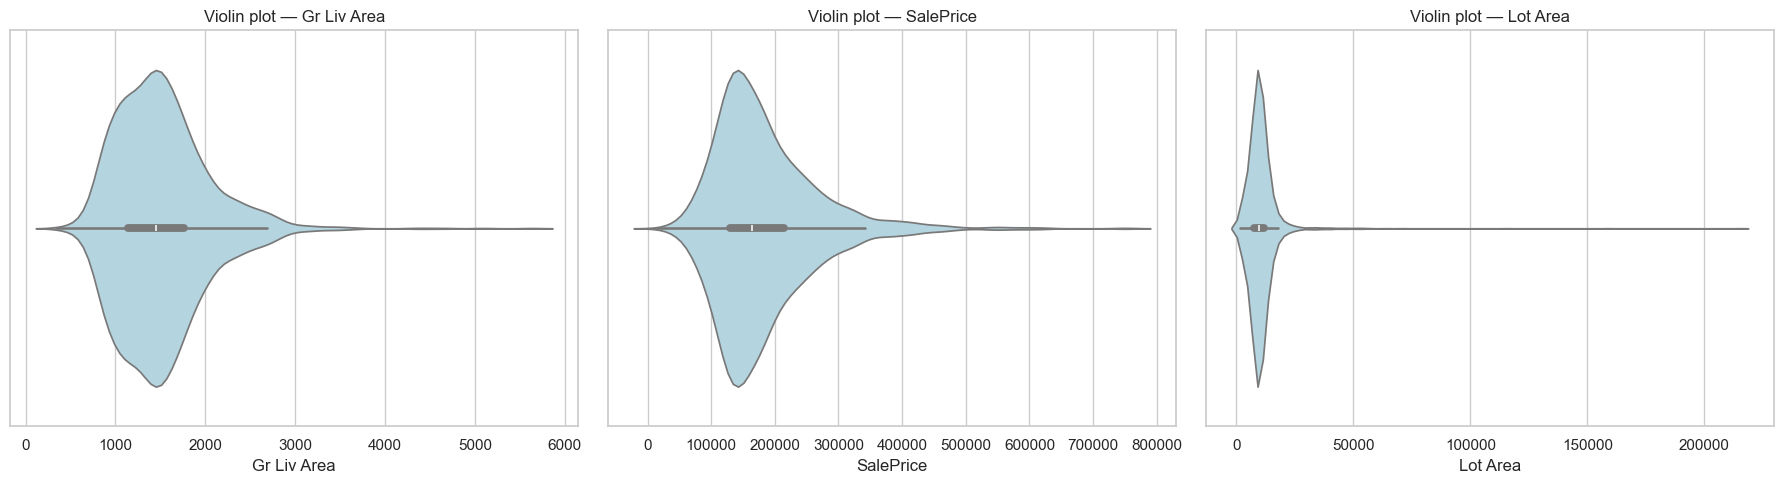

In [22]:
# 6.3 — KDE et Violin plots pour les variables continues
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(variables_continues):
    sns.violinplot(x=df_subset[col].dropna(), ax=axes[i], color='lightblue')
    axes[i].set_title(f'Violin plot — {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

**Interprétation Section 6** *(à compléter)* :
- Pour chaque variable : la distribution est-elle symétrique, étalée à droite, étalée à gauche ?
- La comparaison visuelle moyenne/médiane est-elle cohérente avec le skewness calculé ?
- Observez-vous visuellement des valeurs aberrantes sur les boxplots ?
- Pourquoi ne peut-on pas utiliser un histogramme pour les variables discrètes comme `Overall Qual` ?

---
## Section 7 — Détection préliminaire d'anomalies (IQR et Z-score modifié)

**Objectif** : Appliquer deux méthodes de détection d'outliers sur `SalePrice` et `Lot Area`, puis comparer leurs résultats.

### 7.1 Méthode IQR
Calculez les bornes : [Q1 - 1.5×IQR, Q3 + 1.5×IQR]. Identifiez les observations hors bornes.

In [23]:
# 7.1 — Détection d'outliers par la méthode IQR
variables_outliers = ['SalePrice', 'Lot Area']

for col in variables_outliers:
    data = df_subset[col].dropna()
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr
    
    outliers_iqr = data[(data < borne_inf) | (data > borne_sup)]
    
    print(f"\n--- {col} ---")
    print(f"  Q1 = {q1:.0f}, Q3 = {q3:.0f}, IQR = {iqr:.0f}")
    print(f"  Borne inférieure = {borne_inf:.0f}")
    print(f"  Borne supérieure = {borne_sup:.0f}")
    print(f"  Outliers IQR : {len(outliers_iqr)} ({len(outliers_iqr)/len(data)*100:.1f}%)")


--- SalePrice ---
  Q1 = 130000, Q3 = 215000, IQR = 85000
  Borne inférieure = 2500
  Borne supérieure = 342500
  Outliers IQR : 97 (4.4%)

--- Lot Area ---
  Q1 = 7500, Q3 = 11660, IQR = 4160
  Borne inférieure = 1260
  Borne supérieure = 17900
  Outliers IQR : 99 (4.5%)


### 7.2 Méthode du Z-score modifié

Calculez le z-score modifié pour chaque observation : $Z_{\text{modifié}} = 0.6745 \times \frac{x - \text{médiane}}{\text{MAD}}$. Seuil de détection : $|Z| > 3.5$.

> Le facteur 0.6745 correspond à `scipy.stats.norm.ppf(0.75)` — le 75e percentile de la distribution normale standard.

In [25]:
# 7.2 — Détection d'outliers par le Z-score modifié
for col in variables_outliers:
    data = df_subset[col].dropna()
    mediane = np.median(data)
    mad = np.median(np.abs(data - mediane))
    
    modified_z = 0.6745 * (data - mediane) / mad
    outliers_z = data[np.abs(modified_z) > 3.5]
    
    print(f"\n--- {col} ---")
    print(f"  Médiane = {mediane:.0f}, MAD = {mad:.0f}")
    print(f"  Outliers Z-score modifié (|Z| > 3.5) : {len(outliers_z)} ({len(outliers_z)/len(data)*100:.1f}%)")


--- SalePrice ---
  Médiane = 163500, MAD = 39000
  Outliers Z-score modifié (|Z| > 3.5) : 81 (3.7%)

--- Lot Area ---
  Médiane = 9488, MAD = 2082
  Outliers Z-score modifié (|Z| > 3.5) : 68 (3.1%)


### 7.3 Comparaison et visualisation

Comparez les deux méthodes : créez un graphique coloré par statut outlier pour `SalePrice`.

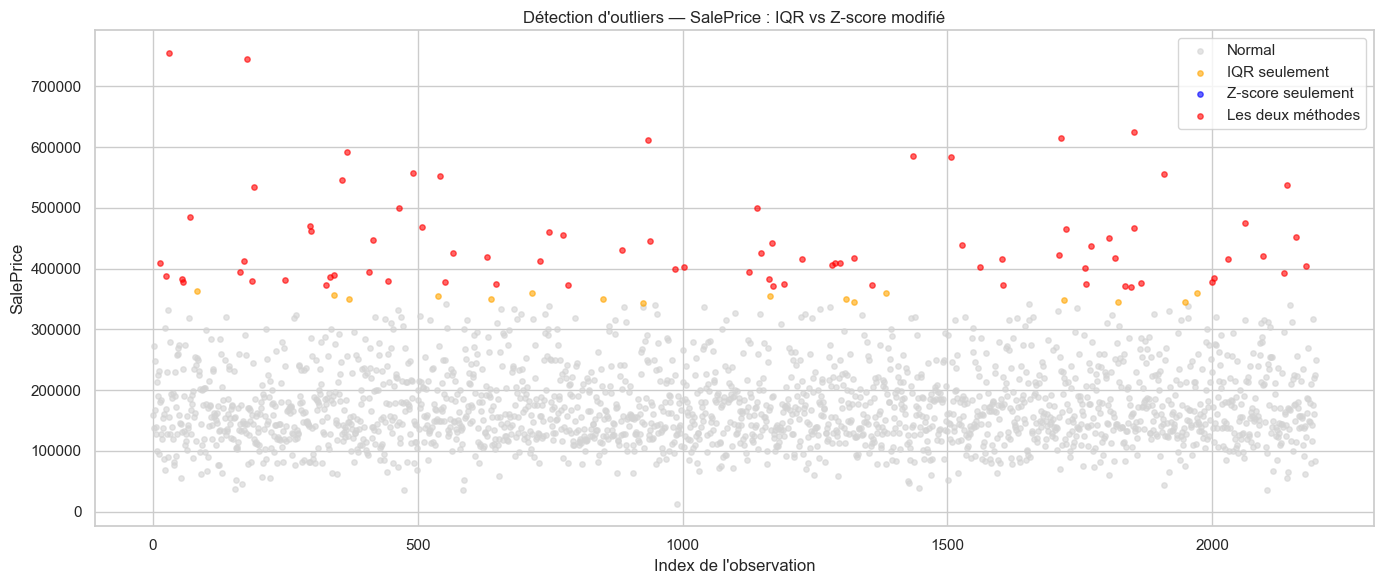


Résumé pour SalePrice :
  Outliers IQR : 97
  Outliers Z-score modifié : 81
  Détectés par les deux : 81


In [26]:
# 7.3 — Comparaison IQR vs Z-score modifié sur SalePrice
col = 'SalePrice'
data = df_subset[col].dropna().reset_index(drop=True)

# IQR
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
is_outlier_iqr = (data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)

# Z-score modifié
mediane = np.median(data)
mad = np.median(np.abs(data - mediane))
modified_z = 0.6745 * (data - mediane) / mad
is_outlier_z = np.abs(modified_z) > 3.5

# Classification
conditions = [
    is_outlier_iqr & is_outlier_z,
    is_outlier_iqr & ~is_outlier_z,
    ~is_outlier_iqr & is_outlier_z,
]
labels = ['Les deux méthodes', 'IQR seulement', 'Z-score seulement']
statut = np.select(conditions, labels, default='Normal')

# Visualisation
df_viz = pd.DataFrame({'Index': range(len(data)), col: data, 'Statut': statut})

plt.figure(figsize=(14, 6))
colors = {'Normal': 'lightgray', 'IQR seulement': 'orange', 'Z-score seulement': 'blue', 'Les deux méthodes': 'red'}
for status, color in colors.items():
    mask = df_viz['Statut'] == status
    plt.scatter(df_viz.loc[mask, 'Index'], df_viz.loc[mask, col], c=color, label=status, alpha=0.6, s=15)

plt.title(f'Détection d\'outliers — {col} : IQR vs Z-score modifié')
plt.xlabel('Index de l\'observation')
plt.ylabel(col)
plt.legend()
plt.tight_layout()
plt.show()

# Tableau récapitulatif
print(f"\nRésumé pour {col} :")
print(f"  Outliers IQR : {is_outlier_iqr.sum()}")
print(f"  Outliers Z-score modifié : {is_outlier_z.sum()}")
print(f"  Détectés par les deux : {(is_outlier_iqr & is_outlier_z).sum()}")

**Interprétation Section 7** *(à compléter)* :
- Les deux méthodes détectent-elles les mêmes observations ?
- Laquelle est plus conservative (détecte plus d'outliers) ? Pourquoi ?
- Les outliers détectés vous semblent-ils des erreurs de données ou des observations légitimes mais extrêmes ?

---
## Section 8 — Analyse bivariée (nuages de points et matrice de corrélation)

**Objectif** : Explorer les relations entre paires de variables. Identifier les corrélations fortes avec `SalePrice` et détecter de potentielles fuites de données.

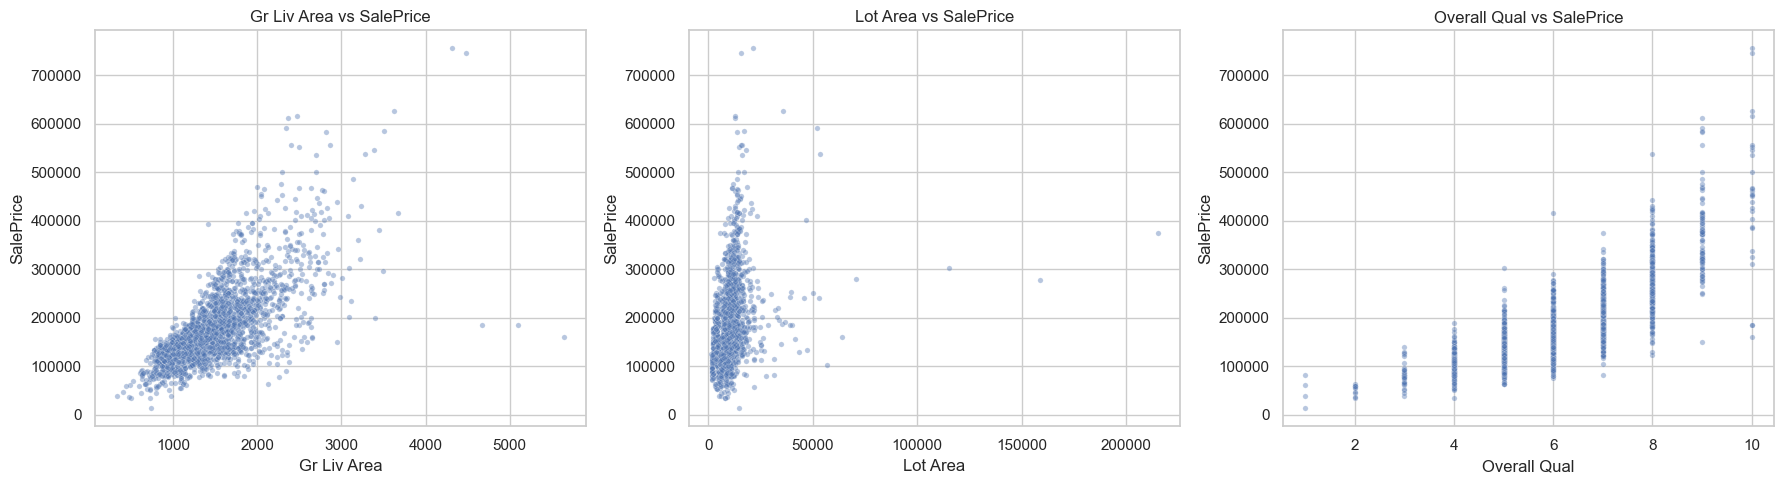

In [27]:
# 8.1 — Nuages de points : chaque variable vs SalePrice
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Gr Liv Area', 'Lot Area', 'Overall Qual']):
    sns.scatterplot(x=df_subset[col], y=df_subset['SalePrice'], ax=axes[i], alpha=0.4, s=15)
    axes[i].set_title(f'{col} vs SalePrice')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

In [ ]:
# 8.2 — Matrice de corrélation de Pearson
corr_matrix = df_subset[variables].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matrice de corrélation — Variables ciblées')
plt.tight_layout()
plt.show()

---
## Section 9 — Analyse multivariée (Pairplot et PCA)

**Objectif** : Visualiser simultanément les relations entre toutes les variables ciblées. Réduire la dimensionnalité avec PCA pour identifier des clusters.

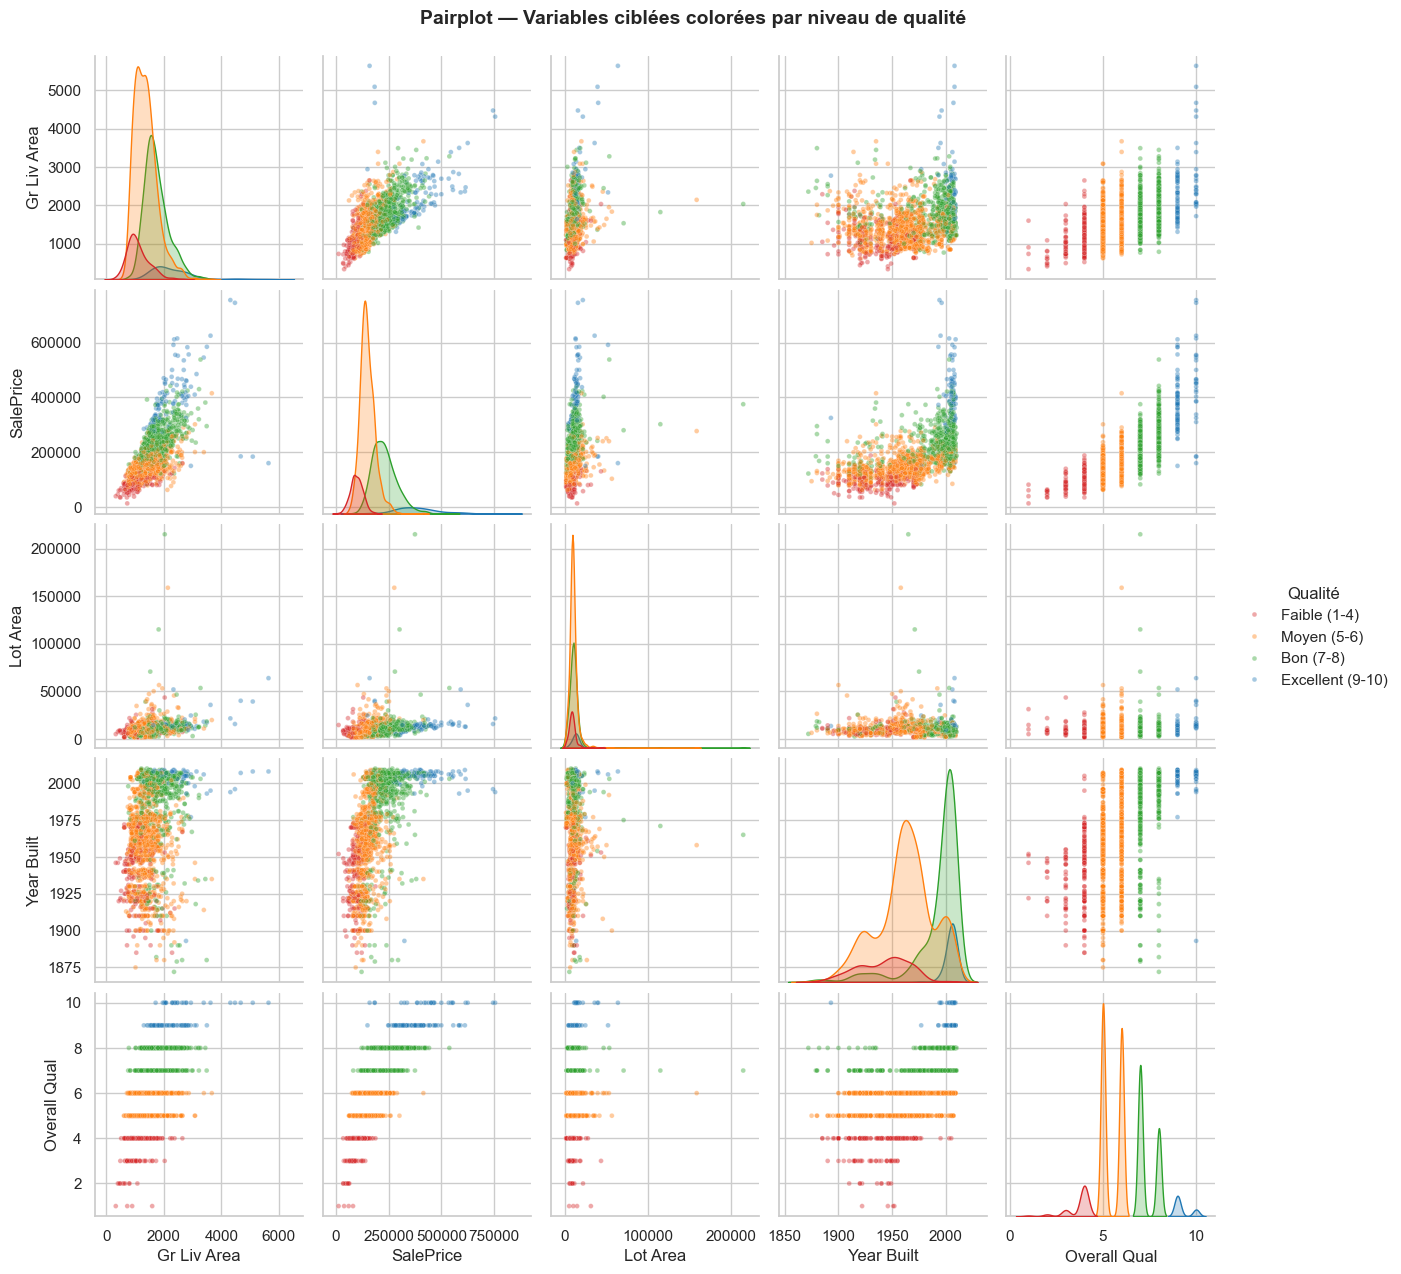

In [37]:
# 9.1 — Pairplot des variables ciblées (coloré par niveau de qualité)
# Création d'une catégorie de qualité pour colorer le pairplot
df_pairplot = df_subset[variables].dropna().copy()
df_pairplot['Qualité'] = pd.cut(df_pairplot['Overall Qual'], bins=[0, 4, 6, 8, 10],
                                 labels=['Faible (1-4)', 'Moyen (5-6)', 'Bon (7-8)', 'Excellent (9-10)'])

sns.pairplot(df_pairplot, hue='Qualité', diag_kind='kde',
             palette={'Faible (1-4)': '#d62728', 'Moyen (5-6)': '#ff7f0e',
                      'Bon (7-8)': '#2ca02c', 'Excellent (9-10)': '#1f77b4'},
             plot_kws={'alpha': 0.4, 's': 12})
plt.suptitle('Pairplot — Variables ciblées colorées par niveau de qualité', y=1.02, fontsize=14, fontweight='bold')
plt.show()

Variance expliquée : PC1 = 56.8%, PC2 = 21.3%
Variance totale expliquée : 78.1%


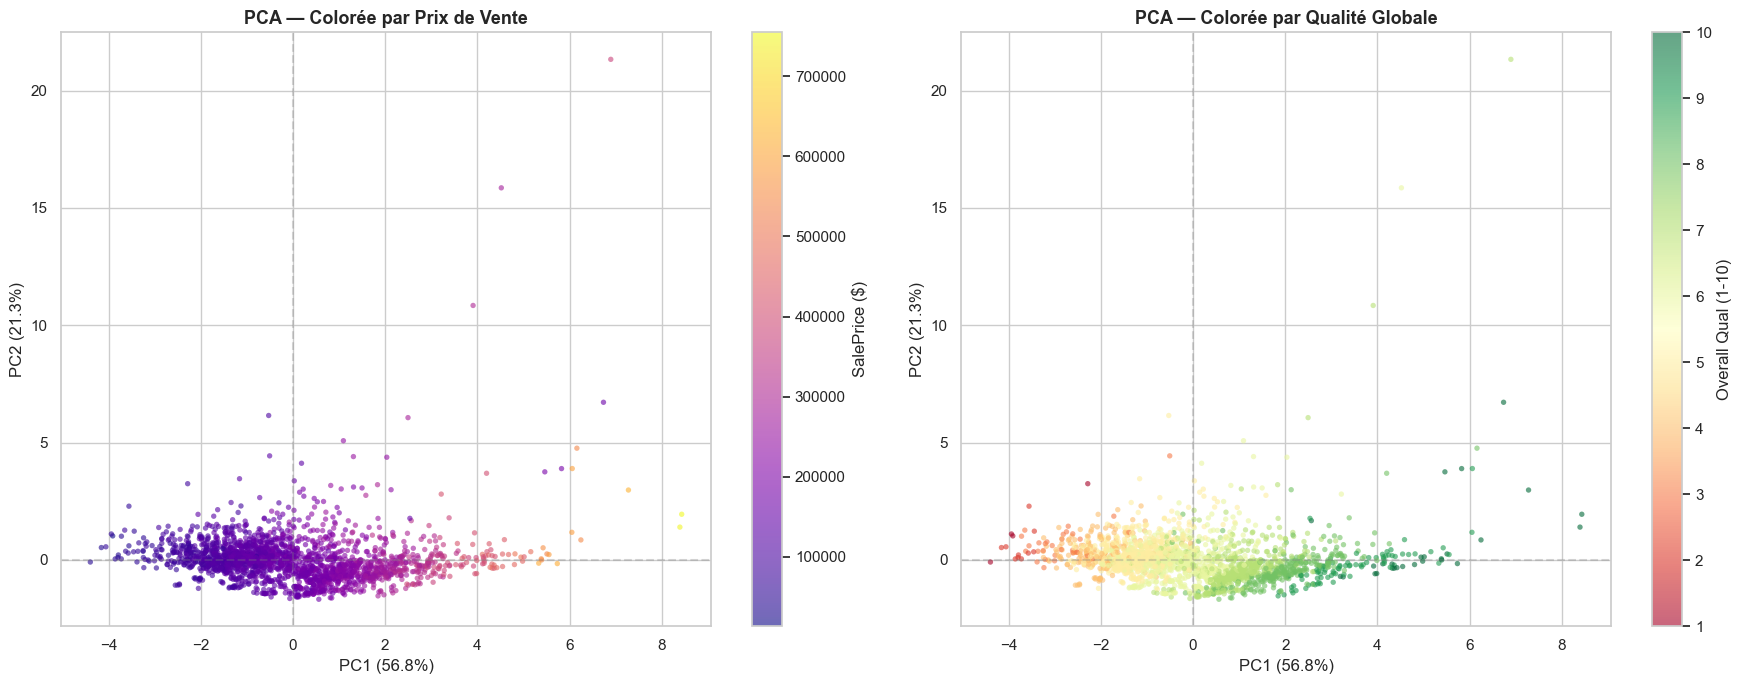

In [38]:
# 9.2 — PCA (Analyse en Composantes Principales)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardisation des données
data_pca = df_subset[variables].dropna()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_pca)

# PCA à 2 composantes
pca = PCA(n_components=2)
composantes = pca.fit_transform(data_scaled)

print(f"Variance expliquée : PC1 = {pca.explained_variance_ratio_[0]:.1%}, PC2 = {pca.explained_variance_ratio_[1]:.1%}")
print(f"Variance totale expliquée : {sum(pca.explained_variance_ratio_):.1%}")

# Visualisation colorée par SalePrice
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Graphique 1 : coloré par SalePrice
sc1 = axes[0].scatter(composantes[:, 0], composantes[:, 1],
                       c=data_pca['SalePrice'], cmap='plasma', alpha=0.6, s=15, edgecolors='none')
plt.colorbar(sc1, ax=axes[0], label='SalePrice ($)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA — Colorée par Prix de Vente', fontsize=13, fontweight='bold')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.3)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.3)

# Graphique 2 : coloré par Overall Qual (catégoriel)
sc2 = axes[1].scatter(composantes[:, 0], composantes[:, 1],
                       c=data_pca['Overall Qual'], cmap='RdYlGn', alpha=0.6, s=15, edgecolors='none')
cbar2 = plt.colorbar(sc2, ax=axes[1], label='Overall Qual (1-10)')
cbar2.set_ticks(range(1, 11))
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA — Colorée par Qualité Globale', fontsize=13, fontweight='bold')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.3)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 10 — Découverte de patterns et génération d'hypothèses

**Objectif** : Identifier des tendances, clusters et relations à partir de toutes les analyses précédentes. Formuler au moins 3 hypothèses testables.

C:\Users\ethan\AppData\Local\Temp\ipykernel_13588\1196889051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Overall Qual', y='SalePrice', data=df_subset, palette='viridis')


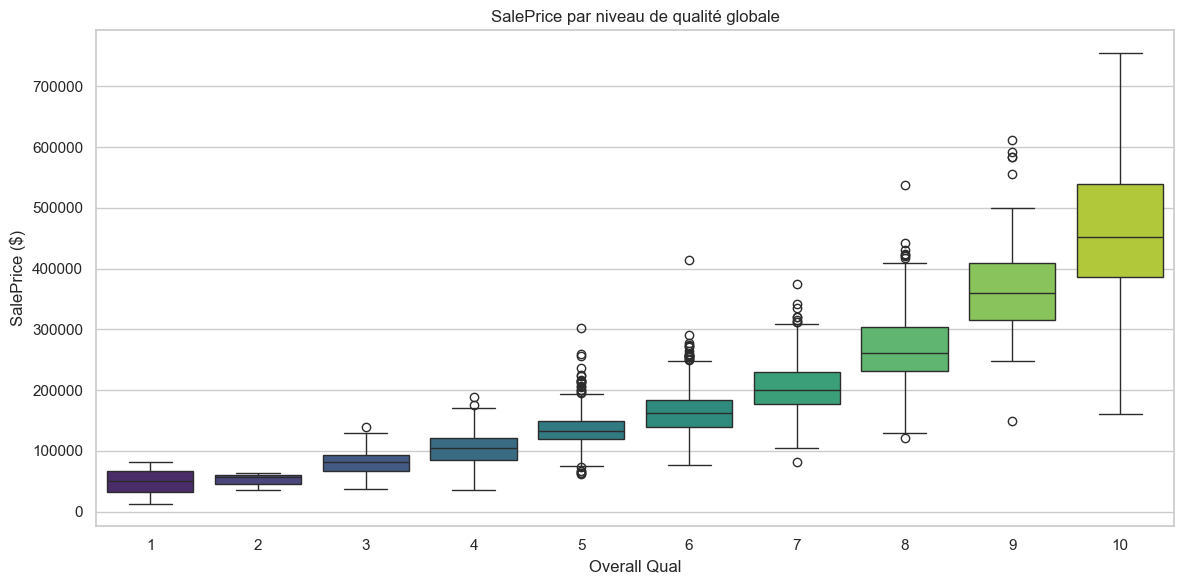

In [30]:
# 10.1 — SalePrice par Overall Qual (boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Overall Qual', y='SalePrice', data=df_subset, palette='viridis')
plt.title('SalePrice par niveau de qualité globale')
plt.xlabel('Overall Qual')
plt.ylabel('SalePrice ($)')
plt.tight_layout()
plt.show()

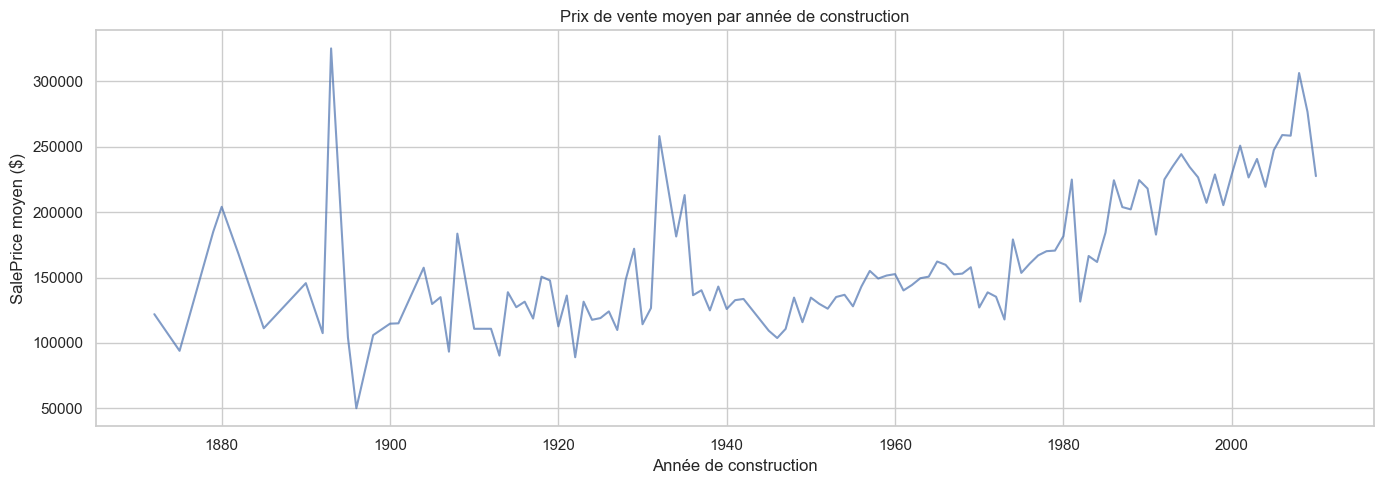

In [31]:
# 10.2 — Évolution du prix moyen par année de construction
prix_par_annee = df_subset.groupby('Year Built')['SalePrice'].mean()
plt.figure(figsize=(14, 5))
plt.plot(prix_par_annee.index, prix_par_annee.values, alpha=0.7)
plt.title('Prix de vente moyen par année de construction')
plt.xlabel('Année de construction')
plt.ylabel('SalePrice moyen ($)')
plt.tight_layout()
plt.show()

### Hypothèses métier *(à compléter)*

Formulez **3 hypothèses testables** en vous appuyant sur vos observations :

| # | Énoncé | Variable(s) | Méthode de vérification envisagée | Observation justificative |
|---|--------|-------------|----------------------------------|---------------------------|
| 1 | *ex: Les maisons avec une qualité globale plus élevée ont un prix de vente significativement plus élevé* | *Overall Qual, SalePrice* | *Corrélation, boxplot par groupe, ANOVA* | *Le boxplot montre une tendance croissante claire* |
| 2 | ... | ... | ... | ... |
| 3 | ... | ... | ... | ... |

---
## Section 11 — Feature Engineering

**Objectif** : Créer de nouvelles variables à partir des données existantes pour enrichir l'analyse. Appliquer des transformations (ratios, log, encodage) et évaluer leur impact.

In [32]:
# 11.1 — Création de nouvelles features
# Ratio : prix par pied carré habitable
df_subset['Prix_par_sqft'] = df_subset['SalePrice'] / df_subset['Gr Liv Area']

# Âge de la maison au moment de la vente (approximation avec 2010 comme année moyenne de vente)
df_subset['Age_maison'] = 2010 - df_subset['Year Built']

# Transformation log pour corriger le skewness
df_subset['Log_SalePrice'] = np.log1p(df_subset['SalePrice'])
df_subset['Log_LotArea'] = np.log1p(df_subset['Lot Area'])
df_subset['Log_GrLivArea'] = np.log1p(df_subset['Gr Liv Area'])

print("Nouvelles features créées :")
print(df_subset[['Prix_par_sqft', 'Age_maison', 'Log_SalePrice', 'Log_LotArea', 'Log_GrLivArea']].describe().round(2))

Nouvelles features créées :
       Prix_par_sqft  Age_maison  Log_SalePrice  Log_LotArea  Log_GrLivArea
count        2197.00     2197.00        2197.00      2197.00        2197.00
mean          121.67       37.97          12.03         9.10           7.27
std            32.35       30.45           0.41         0.51           0.33
min            17.87        0.00           9.48         7.17           5.81
25%           100.31        8.00          11.78         8.92           7.04
50%           120.75       35.00          12.00         9.16           7.28
75%           141.03       56.00          12.28         9.36           7.47
max           276.25      138.00          13.53        12.28           8.64


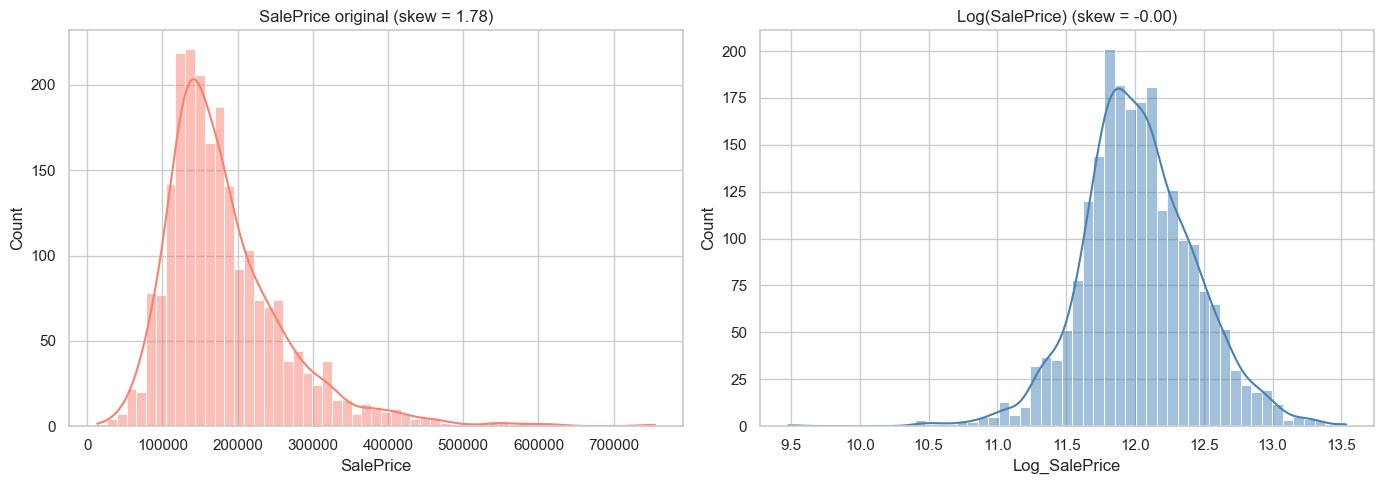

In [33]:
# 11.2 — Effet de la transformation log sur le skewness
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avant transformation
sns.histplot(df_subset['SalePrice'].dropna(), kde=True, ax=axes[0], color='salmon')
axes[0].set_title(f"SalePrice original (skew = {df_subset['SalePrice'].skew():.2f})")

# Après transformation log
sns.histplot(df_subset['Log_SalePrice'].dropna(), kde=True, ax=axes[1], color='steelblue')
axes[1].set_title(f"Log(SalePrice) (skew = {df_subset['Log_SalePrice'].skew():.2f})")

plt.tight_layout()
plt.show()

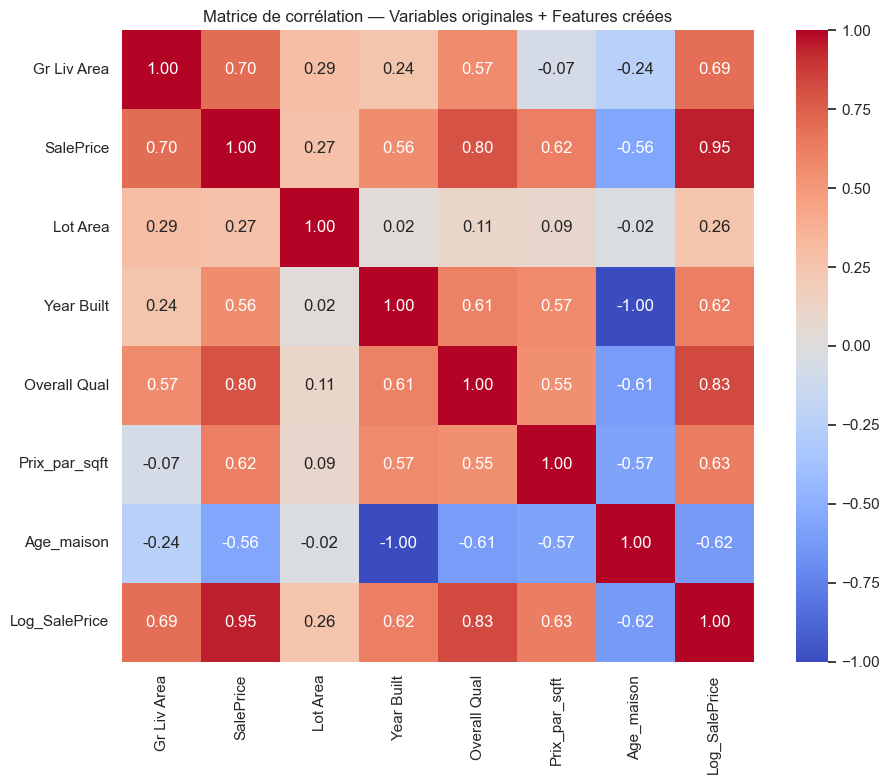

In [34]:
# 11.3 — Matrice de corrélation mise à jour avec les nouvelles features
features_all = ['Gr Liv Area', 'SalePrice', 'Lot Area', 'Year Built', 'Overall Qual',
                'Prix_par_sqft', 'Age_maison', 'Log_SalePrice']

plt.figure(figsize=(10, 8))
sns.heatmap(df_subset[features_all].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matrice de corrélation — Variables originales + Features créées')
plt.tight_layout()
plt.show()

---
## Section 12 — Documentation des résultats et rapport final

**Objectif** : Synthétiser toutes les observations, problèmes de qualité, outliers détectés et features créées dans un rapport structuré.

In [35]:
# 12.1 — Rapport de qualité : complétude par variable
completude = (1 - df.isnull().mean()) * 100
rapport_qualite = pd.DataFrame({
    'Variable': completude.index,
    'Complétude (%)': completude.values.round(1)
}).sort_values('Complétude (%)')

print("=== RAPPORT DE QUALITÉ DES DONNÉES ===")
print(f"\nDimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Doublons : {df.duplicated().sum()}")
print(f"\nVariables avec < 80% de complétude :")
print(rapport_qualite[rapport_qualite['Complétude (%)'] < 80].to_string(index=False))

=== RAPPORT DE QUALITÉ DES DONNÉES ===

Dimensions du dataset : 2197 lignes × 82 colonnes
Doublons : 0

Variables avec < 80% de complétude :
    Variable  Complétude (%)
     Pool QC             0.5
Misc Feature             3.6
       Alley             6.5
       Fence            19.1
Mas Vnr Type            39.5
Fireplace Qu            51.5


### Résumé des résultats *(à compléter)*

**Problèmes de qualité identifiés :**
- ...

**Distributions remarquables :**
- ...

**Outliers détectés :**
- ...

**Features créées :**
- `Prix_par_sqft` : prix par pied carré habitable
- `Age_maison` : âge de la maison (2010 - Year Built)
- `Log_SalePrice`, `Log_LotArea`, `Log_GrLivArea` : transformations log pour corriger l'asymétrie

**Hypothèses formulées :**
- Voir tableau de la Section 10

---
## Checklist avant de rendre

- [ ] Le notebook s'exécute du début à la fin sans erreur (`Restart & Run All`)
- [ ] Chaque section est clairement délimitée par un titre Markdown
- [ ] Chaque graphique a un titre, des labels d'axes, et des légendes si nécessaire
- [ ] Chaque bloc de code est suivi d'une interprétation en Markdown
- [ ] Les 3 hypothèses sont présentées dans le tableau structuré (Section 10)
- [ ] Le tableau récapitulatif des statistiques (Section 5.1) est complet
- [ ] Les features créées sont documentées et leur impact évalué